# $\nu_e$ CC Inclusive Selection + Syst. Analysis

In [1]:
# =============================================================================
# CELL 0 — imports & paths
# =============================================================================
%matplotlib inline
import os, sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

CAFPYANA_WD  = "/home/castalyf/cafpyana"
ANALYSIS_DIR = "."
PLOT_DIR     = "./nuecc_plots_v2"
DF_OUT_DIR   = "./nuecc_dfs"
DF_FILE      = "/exp/sbnd/data/users/castalyf/nue_sel/production_files/gen1/mc1e20_nueCC.df"
TARGET_POT   = 6.6e20
TITLE        = r"SBND $\nu_e$ CC Inclusive"

os.makedirs(PLOT_DIR, exist_ok=True)
for p in [CAFPYANA_WD, CAFPYANA_WD + "/pyanalib", ANALYSIS_DIR]:
    if p not in sys.path:
        sys.path.insert(0, p)

import nue_helpers   as nh
import nue_selection as ns
%load_ext autoreload
%autoreload 2


In [2]:
# =============================================================================
# CELL 1 — load all splits and concatenate
# =============================================================================
with pd.HDFStore(DF_FILE, mode="r") as store:
    keys       = store.keys()
    n_splits   = int(store["split"]["n_split"].iloc[0])
    print(f"Keys   : {keys}")
    print(f"Splits : {n_splits}")

evt_frames   = []
stats_frames = []
pot_frames   = []

for k in range(n_splits):
    evt_frames.append(pd.read_hdf(DF_FILE, key=f"evt_{k}"))
    stats_frames.append(pd.read_hdf(DF_FILE, key=f"stats_{k}"))
    pot_frames.append(pd.read_hdf(DF_FILE, key=f"pot_{k}"))

evtdf   = pd.concat(evt_frames,   axis=0)
statsdf = pd.concat(stats_frames, axis=0)
potdf   = pd.concat(pot_frames,   axis=0)

print(f"\nevtdf   shape : {evtdf.shape}")
print(f"statsdf shape : {statsdf.shape}")
print(f"evtdf index   : {evtdf.index.names}")
print(f"evtdf columns (first 10): {list(evtdf.columns[:10])}")

Keys   : ['/evt_0', '/evt_1', '/hdr_0', '/hdr_1', '/histgenevtdf_0', '/histgenevtdf_1', '/histpotdf_0', '/histpotdf_1', '/pot_0', '/pot_1', '/split', '/stats_0', '/stats_1']
Splits : 2

evtdf   shape : (685791, 393)
statsdf shape : (30, 14)
evtdf index   : ['__ntuple', 'entry', 'rec.dlp..index', 'rec.dlp.particles..index']
evtdf columns (first 10): [('rec', 'dlp', 'match_ids', '', ''), ('rec', 'dlp', 'match_overlaps', '', ''), ('rec', 'dlp', 'cathode_offset', '', ''), ('rec', 'dlp', 'depositions_sum', '', ''), ('rec', 'dlp', 'flash_hypo_pe', '', ''), ('rec', 'dlp', 'flash_total_pe', '', ''), ('rec', 'dlp', 'id', '', ''), ('rec', 'dlp', 'is_cathode_crosser', '', ''), ('rec', 'dlp', 'is_contained', '', ''), ('rec', 'dlp', 'is_fiducial', '', '')]


In [3]:
# ── POT from histpotdf (correct for MC) ──────────────────────────────────────
hist_frames = []
for k in range(n_splits):
    try:
        hist_frames.append(pd.read_hdf(DF_FILE, key=f"histpotdf_{k}"))
    except KeyError:
        pass

histpotdf = pd.concat(hist_frames, axis=0) if hist_frames else pd.DataFrame()
print("histpotdf columns:", histpotdf.columns.tolist())
print(histpotdf.head())

# TotalPOT is the standard column from make_histpotdf
pot_col   = "TotalPOT" if "TotalPOT" in histpotdf.columns else histpotdf.select_dtypes("number").columns[0]
total_pot = float(histpotdf[pot_col].sum())

if total_pot == 0:
    print("WARNING: total_pot=0, check histpotdf. Falling back to pot table.")
    # Inspect what's actually in potdf
    print("potdf head:\n", potdf.head())
    print("potdf columns:", potdf.columns.tolist())

pot_scale = TARGET_POT / total_pot if total_pot > 0 else float("nan")
print(f"Total POT    : {total_pot:.3e}")
print(f"Target POT   : {TARGET_POT:.3e}")
print(f"Scale factor : {pot_scale:.4f}")

histpotdf columns: ['TotalPOT']
                    TotalPOT
__ntuple entry              
0        0      7.545876e+17
2        0      7.556371e+17
7        0      7.491996e+17
6        0      7.522469e+17
3        0      7.523471e+17
Total POT    : 2.256e+19
Target POT   : 6.600e+20
Scale factor : 29.2553


In [4]:
n_true_signal      = int(statsdf["n_true_signal"].sum())
n_inter_after_fm   = int(statsdf["n_after_fm"].sum())       # all interactions after FM
n_inter_after_presel = int(statsdf["n_after_presel"].sum()) # all interactions after FM+FV
n_sig_after_fm     = int(statsdf["n_sig_after_fm"].sum())   # signal after FM
n_sig_after_presel = int(statsdf["n_sig_after_presel"].sum()) # signal after FM+FV

print(f"True signal (pre-cut)   : {n_true_signal:,}  <- denominator")
print(f"Signal after FM         : {n_sig_after_fm:,}  ({n_sig_after_fm/n_true_signal*100:.1f}%)")
print(f"Signal after FM+FV      : {n_sig_after_presel:,}  ({n_sig_after_presel/n_true_signal*100:.1f}%)")
# print(f"Signal visible in evtdf : {len(sig_inter_idx):,}  (should match n_sig_after_presel)")



True signal (pre-cut)   : 670  <- denominator
Signal after FM         : 575  (85.8%)
Signal after FM+FV      : 570  (85.1%)


In [5]:
# =============================================================================
# CELL 3 — alignment helpers (same as before)
# =============================================================================
il               = nh.inter_levels(evtdf)
presel_inter     = evtdf.groupby(level=il).size().index
truth_cat_presel = evtdf.groupby(level=il).first()  # interaction-level view

# NOTE: with the new df, truth_info_0 is not written separately.
# truth categories come from classify_truth or from statsdf aggregate counts.
# For per-interaction truth_cat, use classify_truth:
truth_cat_presel = ns.classify_truth(evtdf, verbose=True)
true_ke_all       = ns.true_leading_electron_ke(evtdf)
true_costheta_all = ns.true_leading_electron_costheta(evtdf)

sig_inter_idx   = truth_cat_presel[truth_cat_presel == 0].index
sig_mask_presel = presel_inter.isin(sig_inter_idx)

print(f"\nSignal visible in evtdf : {len(sig_inter_idx):,}")
print(f"True denominator        : {n_true_signal:,}")

classify_truth: reading true-interaction flags …
  is_nu        :  138,167
  is_cc        :  107,042
  is_fv (true) :  118,382
  true_elec    :    1,082
  true_muon    :  102,531
  has_pi0      :   19,319

=== Truth category summary ===
  cat  0  nueCC FV (signal)     :      570
  cat  1  nueCC out FV          :       29
  cat  2  numuCC + π⁰           :   10,927
  cat  3  NC π⁰                 :    6,989
  cat  4  other numuCC          :   88,224
  cat  5  other NC              :   24,136
  cat  6  cosmic                :    6,120
  cat  7  other neutrino        :    7,292
  total                     :  144,287
=== RAW tp.ke VALUES (primary electrons) ===
Number of primary electrons : 1,779
Raw min  : 9.6096
Raw max  : 4452.2093
Raw mean : 582.5036
Raw median: 351.8604
After *1000 (GeV→MeV)  → min/max: 9609.6 – 4452209.3 MeV
After *1     (already MeV) → min/max: 9.6 – 4452.2 MeV

Signal visible in evtdf : 570
True denominator        : 670


Building cut flow:   0%|          | 0/4 [00:00<?, ?it/s]

=== RAW tp.ke VALUES (primary electrons) ===
Number of primary electrons : 1,779
Raw min  : 9.6096
Raw max  : 4452.2093
Raw mean : 582.5036
Raw median: 351.8604
After *1000 (GeV→MeV)  → min/max: 9609.6 – 4452209.3 MeV
After *1     (already MeV) → min/max: 9.6 – 4452.2 MeV

Cut                            N inter    Purity    Efficiency
----------------------------------------------------------------
  No cut (pre-FM/FV)               670     0.00%        100.0%
  Flash match                  251,656     0.23%         85.8%
  In FV                        144,287     0.40%         85.1%
  Final state topology           4,060    15.37%         81.3%


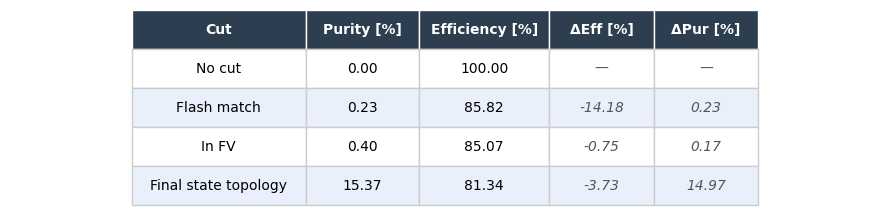

In [6]:
# =============================================================================
# CELL 4 — cut flow + table
# =============================================================================
cut_flow = ns.build_cut_flow(evtdf)
true_ke_all       = ns.true_leading_electron_ke(evtdf)
true_costheta_all = ns.true_leading_electron_costheta(evtdf)

def _purity(stage_idx):
    n_no7 = int((truth_cat_presel.reindex(stage_idx).fillna(7) != 7).sum())
    if n_no7 == 0:
        return float("nan")
    return int((truth_cat_presel.reindex(stage_idx) == 0).sum()) / n_no7

se_idx   = cut_flow["single_electron"]["inter_index"]
n_sig_se = int((truth_cat_presel.reindex(se_idx) == 0).sum())

# ── Efficiencies: signal counts from statsdf, denominator = n_true_signal ─────
eff_fm  = n_sig_after_fm     / n_true_signal if n_true_signal > 0 else float("nan")
eff_fv  = n_sig_after_presel / n_true_signal if n_true_signal > 0 else float("nan")
eff_se  = n_sig_se           / n_true_signal if n_true_signal > 0 else float("nan")

# ── Purity: signal / (non-cat7 selected) — computable for all stages ─────────
# FM: n_sig_after_fm / n_inter_after_fm (excluding cat7 not available from statsdf,
#     but cat7 fraction is small so use total as approximation)
pur_fm  = n_sig_after_fm     / n_inter_after_fm     if n_inter_after_fm     > 0 else float("nan")
pur_fv  = n_sig_after_presel / n_inter_after_presel if n_inter_after_presel > 0 else float("nan")
pur_se  = _purity(se_idx)

W = 28
print(f"\n{'Cut':<{W}} {'N inter':>9}  {'Purity':>8}  {'Efficiency':>12}")
print("-" * (W + 36))
print(f"  {'No cut (pre-FM/FV)':<{W-2}} {n_true_signal:>9,}  {'0.00%':>8}  {'100.0%':>12}")
print(f"  {'Flash match':<{W-2}} {n_inter_after_fm:>9,}  {pur_fm*100:>7.2f}%  {eff_fm*100:>11.1f}%")
print(f"  {'In FV':<{W-2}} {n_inter_after_presel:>9,}  {pur_fv*100:>7.2f}%  {eff_fv*100:>11.1f}%")
print(f"  {'Final state topology':<{W-2}} {len(se_idx):>9,}  {pur_se*100:>7.2f}%  {eff_se*100:>11.1f}%")

CUT_DISPLAY = ["No cut", "Flash match", "In FV", "Final state topology"]
purs_table  = [0.0,    pur_fm, pur_fv, pur_se]
effs_table  = [1.0,    eff_fm, eff_fv, eff_se]
fig_tbl, ax_tbl = plt.subplots(figsize=(9, 2.6))
nh.create_purity_efficiency_table(purs_table, effs_table, CUT_DISPLAY, ax_tbl)
fig_tbl.tight_layout()
plt.show()
nh.save_plot("pur_eff_table", fig=fig_tbl, folder_name=PLOT_DIR)

In [8]:
# =============================================================================
# CELL 6 — save topo selection df, free evtdf
# =============================================================================
import gc
SEL_TOPO_FILE = os.path.join(DF_OUT_DIR, "selected_nuecc_topo.df")

_stage_idx_topo = {
    "precut"          : presel_inter,
    "valid_flashmatch": presel_inter,    # all presel passed FM
    "fiducial"        : presel_inter,    # all presel passed FV
    "single_electron" : se_idx,
}

sel_topo = nh.build_and_save_selection(
    path             = SEL_TOPO_FILE,
    presel_inter     = presel_inter,
    truth_cat_presel = truth_cat_presel,
    reco_ke          = ns.leading_electron_ke(evtdf),
    reco_cos         = ns.leading_electron_costheta(evtdf),
    reco_p           = ns.leading_electron_p(evtdf),        # ← new
    true_ke          = true_ke_all,
    true_cos         = true_costheta_all,
    true_p           = ns.true_leading_electron_p(evtdf),   # ← new
    stage_idx_dict   = _stage_idx_topo,
    cut_names        = list(_stage_idx_topo.keys()),
    pot_scale        = pot_scale,
)
print(f"sel_topo saved: {sel_topo.shape}")
# evtdf kept alive — threshold scans still need it

Saved selection df → ./nuecc_dfs/selected_nuecc_topo.df
  shape=(144287, 13)  size=0.7 MB
sel_topo saved: (144287, 13)


/home/castalyf/cafpyana/envs/venv_py310_cafpyana/lib/python3.10/site-packages/tables/attributeset.py:462: NaturalNameWarning: object name is not a valid Python identifier: 'axis1_namerec.dlp..index'; it does not match the pattern ``^[a-zA-Z_][a-zA-Z0-9_]*$``; you will not be able to use natural naming to access this object; using ``getattr()`` will still work, though
  check_attribute_name(name)


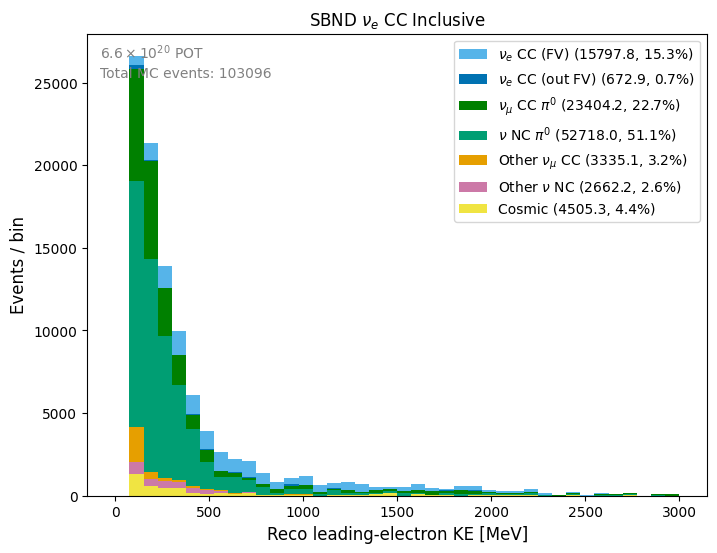

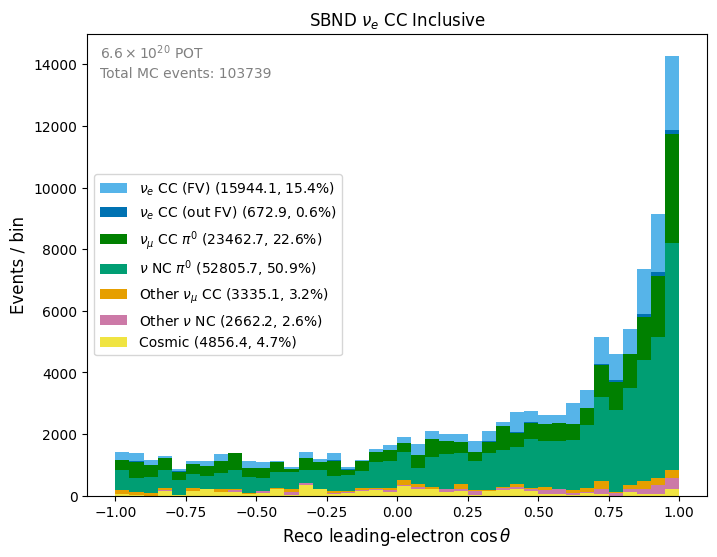

In [9]:
# =============================================================================
# CELL 7 — topology stacked histograms (from sel_topo)

DISPLAY_CATS = [0, 1, 2, 3, 4, 5, 6]
def _topo_cat(col, cat):
    mask = sel_topo["sel_single_electron"] & (sel_topo["truth_cat"] == cat)
    return sel_topo.loc[mask, col].dropna().values

_labels = [nh.CAT_LABELS[c] for c in DISPLAY_CATS]
_colors = [nh.CAT_COLORS[c] for c in DISPLAY_CATS]
bins_ke  = np.concatenate([np.linspace(0, 3000, 41)])
bins_cos = np.linspace(-1, 1, 41)

fig_ke, ax_ke = plt.subplots(figsize=(8, 6))
nh.plot_stacked_hist(
    series_list=[_topo_cat("reco_ke", c) for c in DISPLAY_CATS],
    labels=_labels, colors=_colors, bins=bins_ke, weights=pot_scale,
    xlabel="Reco leading-electron KE [MeV]", title=fr"{TITLE}",
    pot_label=fr"$6.6\times10^{{20}}$ POT", ax=ax_ke, invert_stack_order=True,
)
plt.show()
nh.save_plot("hist_reco_ke", fig=fig_ke, folder_name=PLOT_DIR)

fig_cos, ax_cos = plt.subplots(figsize=(8, 6))
nh.plot_stacked_hist(
    series_list=[_topo_cat("reco_costheta", c) for c in DISPLAY_CATS],
    labels=_labels, colors=_colors, bins=bins_cos, weights=pot_scale,
    xlabel=r"Reco leading-electron $\cos\theta$", title=fr"{TITLE}",
    pot_label=fr"$6.6\times10^{{20}}$ POT", ax=ax_cos, invert_stack_order=True,
)
plt.show()
nh.save_plot("hist_reco_costheta", fig=fig_cos, folder_name=PLOT_DIR)

In [10]:
# =============================================================================
# CELL 10 — shower qual cuts + save qual df + del evtdf
# =============================================================================

cut_flow_sq = ns.shower_qual_cuts(evtdf)

def _row_stats(stage_idx):
    n_no7 = int((truth_cat_presel.reindex(stage_idx).fillna(7) != 7).sum())
    n_sig  = int((truth_cat_presel.reindex(stage_idx) == 0).sum())
    pur    = n_sig / n_no7     if n_no7           > 0 else float("nan")
    eff    = n_sig / n_true_signal if n_true_signal > 0 else float("nan")
    return len(stage_idx), pur, eff

# FM/FV from statsdf; topology+ from cut_flow_sq
sq_names  = ns.CUT_NAMES_MORE[ns.CUT_NAMES_MORE.index("single_electron") + 1:]
sq_labels = ns.CUT_LABELS_MORE[ns.CUT_NAMES_MORE.index("single_electron") + 1:]
sq_rows   = {name: _row_stats(cut_flow_sq[name]["inter_index"]) for name in sq_names}

W = 28
print(f"\n{'Cut':<{W}} {'N inter':>9}  {'Purity':>8}  {'Efficiency':>12}")
print("-" * (W + 36))
print(f"  {'No cut (pre-FM/FV)':<{W-2}} {n_true_signal:>9,}  {'—':>8}  {'100.0%':>12}")
print(f"  {'Flash match':<{W-2}} {n_inter_after_fm:>9,}  {'—':>8}  {eff_fm*100:>11.1f}%")
print(f"  {'In FV':<{W-2}} {n_inter_after_presel:>9,}  {pur_fv*100:>7.1f}%  {eff_fv*100:>11.1f}%")
print(f"  {'Final state topology':<{W-2}} {len(se_idx):>9,}  {pur_se*100:>7.1f}%  {eff_se*100:>11.1f}%")
for name, label in zip(sq_names, sq_labels):
    n_i, pur, eff = sq_rows[name]
    print(f"  {label:<{W-2}} {n_i:>9,}  {pur*100:>7.1f}%  {eff*100:>11.1f}%")

# ── Save qual selection df ────────────────────────────────────────────────────
SEL_QUAL_FILE = os.path.join(DF_OUT_DIR, "selected_nuecc_qual.df")

_stage_idx_qual = {
    "precut"          : presel_inter,
    "valid_flashmatch": presel_inter,
    "fiducial"        : presel_inter,
}
for _name in ns.CUT_NAMES_MORE:
    if _name not in _stage_idx_qual:
        _stage_idx_qual[_name] = cut_flow_sq[_name]["inter_index"]

sel_qual = nh.build_and_save_selection(
    path             = SEL_QUAL_FILE,
    presel_inter     = presel_inter,
    truth_cat_presel = truth_cat_presel,
    reco_ke          = ns.leading_electron_ke(evtdf),
    reco_cos         = ns.leading_electron_costheta(evtdf),
    reco_p           = ns.leading_electron_p(evtdf),
    true_ke          = true_ke_all,
    true_cos         = true_costheta_all,
    true_p           = ns.true_leading_electron_p(evtdf),
    stage_idx_dict   = _stage_idx_qual,
    cut_names        = ns.CUT_NAMES_MORE,
    pot_scale        = pot_scale,
)

del evtdf
gc.collect()
print(f"evtdf freed. sel_qual shape: {sel_qual.shape}")

Building cut flow:   0%|          | 0/4 [00:00<?, ?it/s]

Applying extra shower-quality cuts:   0%|          | 0/2 [00:00<?, ?it/s]


Cut                            N inter    Purity    Efficiency
----------------------------------------------------------------
  No cut (pre-FM/FV)               670         —        100.0%
  Flash match                  251,656         —         85.8%
  In FV                        144,287      0.4%         85.1%
  Final state topology           4,060     15.4%         81.3%
  Electron PID score               781     58.4%         58.4%
  Electron Primary score           606     66.4%         52.5%
Saved selection df → ./nuecc_dfs/selected_nuecc_qual.df
  shape=(144287, 15)  size=0.7 MB
evtdf freed. sel_qual shape: (144287, 15)


/home/castalyf/cafpyana/envs/venv_py310_cafpyana/lib/python3.10/site-packages/tables/attributeset.py:462: NaturalNameWarning: object name is not a valid Python identifier: 'axis1_namerec.dlp..index'; it does not match the pattern ``^[a-zA-Z_][a-zA-Z0-9_]*$``; you will not be able to use natural naming to access this object; using ``getattr()`` will still work, though
  check_attribute_name(name)


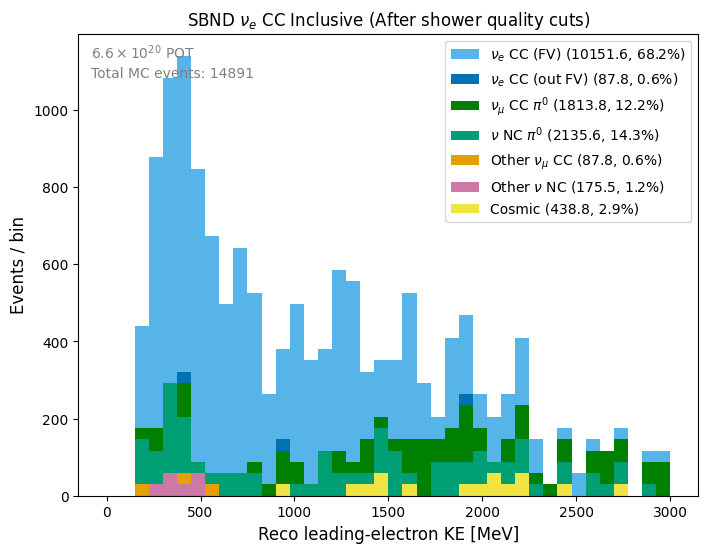

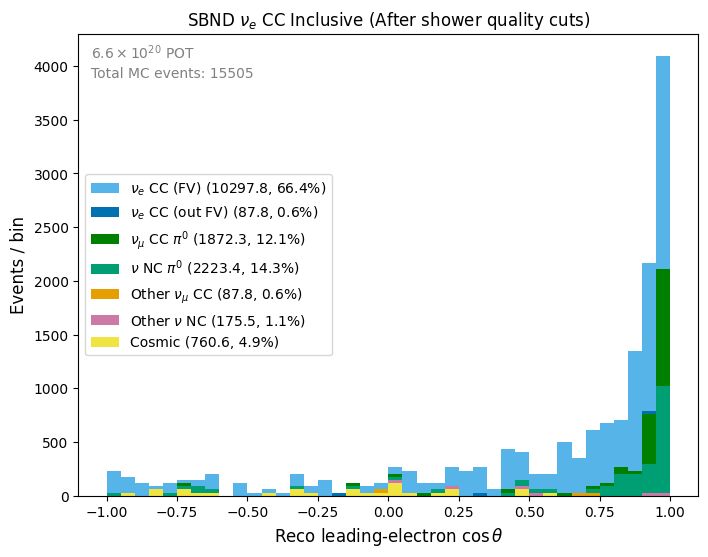

In [11]:
# ── Final stacked histograms ──────────────────────────────────────────────────
final_col = f"sel_{ns.CUT_NAMES_MORE[-1]}"

def _qual_cat(col, cat):
    mask = sel_qual[final_col] & (sel_qual["truth_cat"] == cat)
    mask = mask & sel_qual["reco_ke"].notna() & sel_qual["reco_costheta"].notna()
    return sel_qual.loc[mask, col].values

fig_ke2, ax_ke2 = plt.subplots(figsize=(8, 6))
nh.plot_stacked_hist(
    series_list=[_qual_cat("reco_ke", c) for c in DISPLAY_CATS],
    labels=_labels, colors=_colors,
    bins=np.concatenate([np.linspace(0, 3000, 41)]),
    weights=pot_scale, xlabel="Reco leading-electron KE [MeV]",
    title=fr"{TITLE} (After shower quality cuts)",
    pot_label=fr"$6.6\times10^{{20}}$ POT", ax=ax_ke2, invert_stack_order=True,
)
plt.show()
nh.save_plot("hist_reco_ke_final", fig=fig_ke2, folder_name=PLOT_DIR)

fig_cos2, ax_cos2 = plt.subplots(figsize=(8, 6))
nh.plot_stacked_hist(
    series_list=[_qual_cat("reco_costheta", c) for c in DISPLAY_CATS],
    labels=_labels, colors=_colors, bins=np.linspace(-1, 1, 41),
    weights=pot_scale, xlabel=r"Reco leading-electron $\cos\theta$",
    title=fr"{TITLE} (After shower quality cuts)",
    pot_label=fr"$6.6\times10^{{20}}$ POT", ax=ax_cos2, invert_stack_order=True,
)
plt.show()
nh.save_plot("hist_reco_costheta_final", fig=fig_cos2, folder_name=PLOT_DIR)

In [ ]:
# =============================================================================
# CELL S0 — load mcnu weights table
# =============================================================================
import gc
import uproot
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

evtdf   = pd.concat(evt_frames,   axis=0)
# In the loading cell, add:
mcnu_frames = []
with pd.HDFStore(DF_FILE, mode="r") as store:
    n_splits = int(store["split"]["n_split"].iloc[0])
    for k in range(n_splits):
        if f"/mcnu_{k}" in store.keys():
            mcnu_frames.append(store[f"mcnu_{k}"])

mcnu_df = pd.concat(mcnu_frames, axis=0) if mcnu_frames else pd.DataFrame()
print(f"mcnu_df shape: {mcnu_df.shape}")
print(f"mcnu columns sample: {list(mcnu_df.columns[:5])}")

# Verify universe weights are present
bnb_cols   = [c for c in mcnu_df.columns if any("bnb"   in str(p).lower() for p in c)]
genie_cols = [c for c in mcnu_df.columns if any("genie" in str(p).lower() for p in c)]
print(f"BNB universe columns  : {len(bnb_cols)}")
print(f"GENIE universe columns: {len(genie_cols)}")